In [1]:
from pathlib import Path
import zipfile
import io
import re
import json
import math
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

RUNS = [
    {
        "target_gap": 1e-4,
        "path": Path(r"C:\Users\omkarp\IdeaProjects\VSCode\Large-scale-LBBD-Optimization\runs\tolerance runs\2026-09-07_145250_small_with_redirection_LBBD_withPV_withBESS")
    },
    {
        "target_gap": 5e-5,
        "path": Path(r"C:\Users\omkarp\IdeaProjects\VSCode\Large-scale-LBBD-Optimization\runs\tolerance runs\2026-09-07_154307_small_with_redirection_LBBD_withPV_withBESS")
    },
    {
        "target_gap": 2e-5,
        "path": Path(r"C:\Users\omkarp\IdeaProjects\VSCode\Large-scale-LBBD-Optimization\runs\tolerance runs\2026-09-07_162633_small_with_redirection_LBBD_withPV_withBESS")
    },
    {
        "target_gap": 25e-6,
        "path": Path(r"C:\Users\omkarp\IdeaProjects\VSCode\Large-scale-LBBD-Optimization\runs\tolerance runs\2026-09-08_085830_small_with_redirection_LBBD_withPV_withBESS")
    },
    {
        "target_gap": 1e-5,
        "path": Path(r"C:\Users\omkarp\IdeaProjects\VSCode\Large-scale-LBBD-Optimization\runs\tolerance runs\2026-09-07_173810_small_with_redirection_LBBD_withPV_withBESS")
    },
]

OUTPUT_DIR = Path("LBBD_tolerance_diagnostics")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

THREE_METHOD_HEADLINE = Path("manuscript_headline_stats.csv")
THREE_METHOD_COMPARISON = Path("manuscript_method_comparison.csv")

Loaded C:\Users\omkarp\IdeaProjects\VSCode\Large-scale-LBBD-Optimization\runs\tolerance runs\2026-09-07_145250_small_with_redirection_LBBD_withPV_withBESS for target 0.0001
Loaded C:\Users\omkarp\IdeaProjects\VSCode\Large-scale-LBBD-Optimization\runs\tolerance runs\2026-09-07_154307_small_with_redirection_LBBD_withPV_withBESS for target 5e-05
Loaded C:\Users\omkarp\IdeaProjects\VSCode\Large-scale-LBBD-Optimization\runs\tolerance runs\2026-09-07_162633_small_with_redirection_LBBD_withPV_withBESS for target 2e-05
Loaded C:\Users\omkarp\IdeaProjects\VSCode\Large-scale-LBBD-Optimization\runs\tolerance runs\2026-09-08_085830_small_with_redirection_LBBD_withPV_withBESS for target 2.5e-05
Loaded C:\Users\omkarp\IdeaProjects\VSCode\Large-scale-LBBD-Optimization\runs\tolerance runs\2026-09-07_173810_small_with_redirection_LBBD_withPV_withBESS for target 1e-05


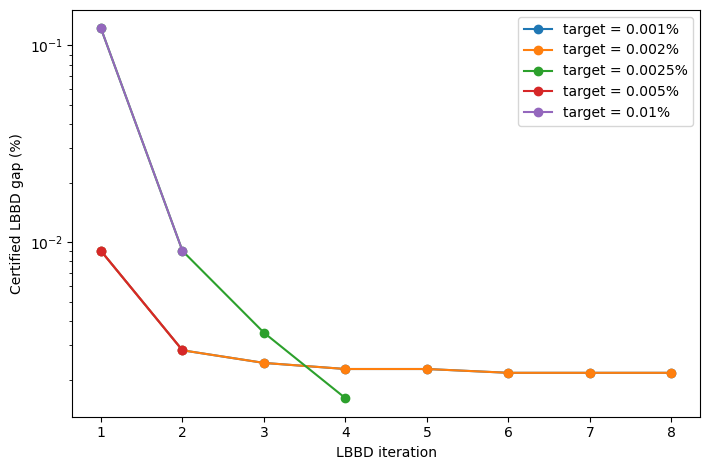

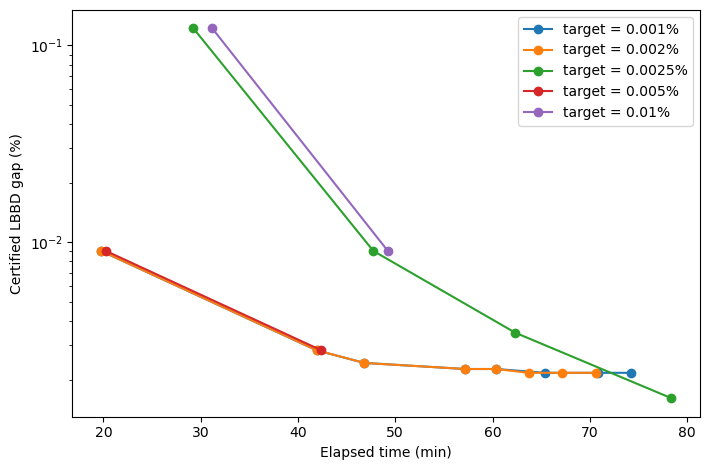

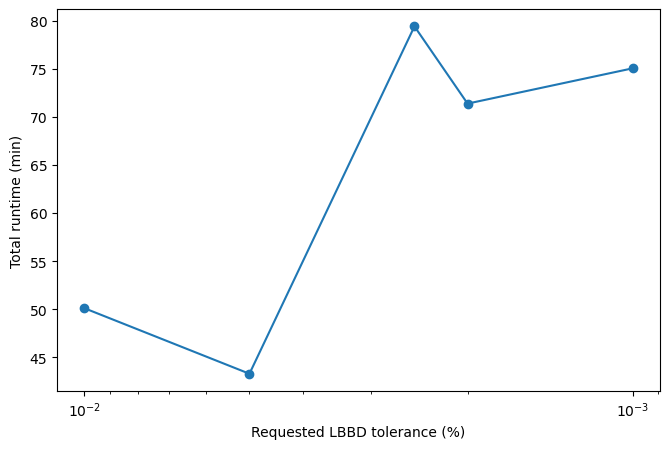

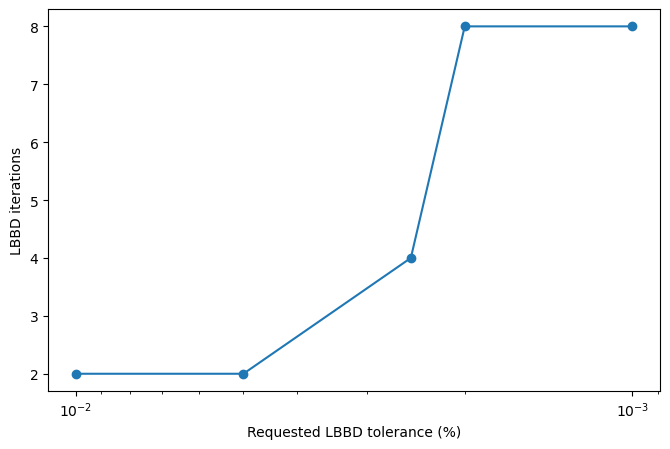

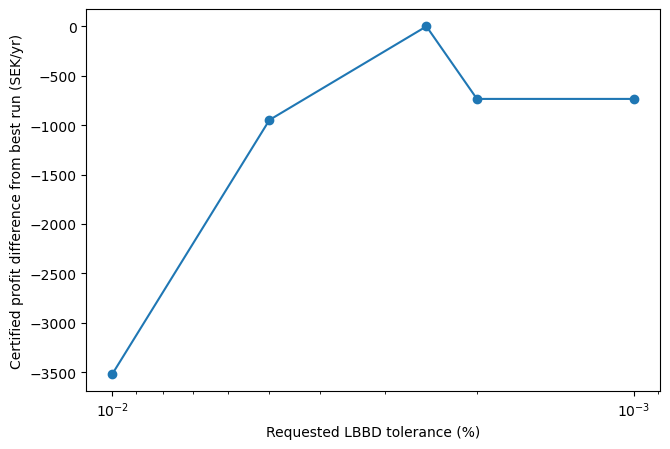

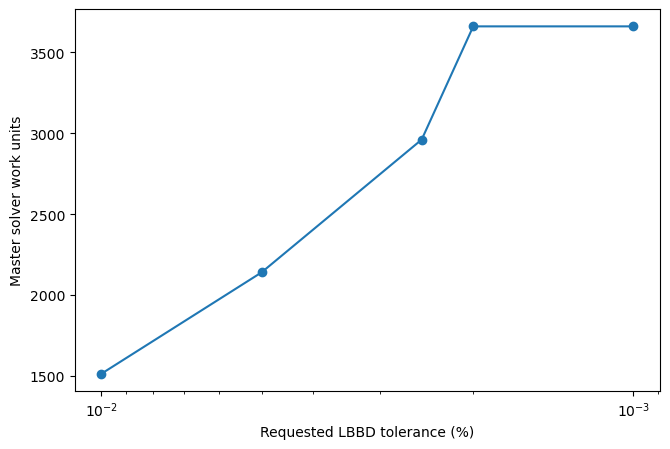


LBBD tolerance diagnostic summary
Tolerance runs analysed: 5
Target 0.01%: final gap=0.00904843%, iterations=2, runtime=50.081 min, profit=126987849.148 SEK/yr, target reached=True
Target 0.005%: final gap=0.00283108%, iterations=2, runtime=43.256 min, profit=126990418.176 SEK/yr, target reached=True
Target 0.0025%: final gap=0.00161649%, iterations=4, runtime=79.438 min, profit=126991365.529 SEK/yr, target reached=True
Target 0.002%: final gap=0.00217606%, iterations=8, runtime=71.393 min, profit=126990631.159 SEK/yr, target reached=False
Target 0.001%: final gap=0.00217606%, iterations=8, runtime=75.067 min, profit=126990631.159 SEK/yr, target reached=False

Certified objective spread across tolerances: 3516.382 SEK/yr (0.00276899%).
Tightest/loosest runtime ratio: 1.499.
Iterations changed from 2 at the loosest tolerance to 8 at the tightest tolerance.
Peak process-tree RSS range: 17.535–25.491 GB.
Maximum annual slack across tolerance runs: 0.000000 kWh.

Solution-stability ranges

,Requested LBBD gap (%),Final certified gap (%),Best achieved gap (%),Target reached,Iterations,Runtime (min),Runtime multiplier,Best feasible LB (SEK/yr),Global UB (SEK/yr),Final bound width (SEK),...,Exact annual solver time (s),Exact annual work units,Cuts added,Annual LP cuts,Annual core cuts,Exact configuration cuts,Partial logic cuts,Distinct candidates,Cached iterations,Annual slack (kWh)
0,0.0100,0.009048,0.009048,True,2,50.080998,1.000000,1.269878e+08,1.269993e+08,11491.440955,...,103.43,140.68,2.0,0.0,0.0,2.0,0.0,2,0,0.0
1,0.0050,0.002831,0.002831,True,2,43.256074,0.863722,1.269904e+08,1.269940e+08,3595.305467,...,95.95,144.31,2.0,0.0,0.0,2.0,0.0,2,0,0.0
2,0.0025,0.001616,0.001616,True,4,79.438321,1.586197,1.269914e+08,1.269934e+08,2052.829840,...,193.59,269.06,4.0,0.0,0.0,4.0,0.0,4,0,0.0
3,0.0020,0.002176,0.002176,False,8,71.393408,1.425559,1.269906e+08,1.269934e+08,2763.447928,...,142.20,214.31,2.0,0.0,0.0,2.0,0.0,3,5,0.0
4,0.0010,0.002176,0.002176,False,8,75.067483,1.498921,1.269906e+08,1.269934e+08,2763.447928,...,142.06,214.31,2.0,0.0,0.0,2.0,0.0,3,5,0.0



Solution stability:


,metric,minimum,maximum,absolute_spread,relative_spread_percent
0,slow_chargers,7.200000e+01,7.200000e+01,0.000000,0.000000
1,medium_chargers,4.020000e+02,4.020000e+02,0.000000,0.000000
2,fast_chargers,4.100000e+01,4.100000e+01,0.000000,0.000000
3,pv_panels,1.502900e+04,1.508300e+04,54.000000,0.358432
4,bess_units,3.200000e+02,3.220000e+02,2.000000,0.623441
5,energy_redirected_kwh,4.477299e+05,4.557875e+05,8057.545397,1.774558
6,share_redirected_public_demand,1.762055e-02,1.793766e-02,0.000317,1.774558
7,annual_profit_sek,1.269878e+08,1.269914e+08,3516.381560,0.002769



All diagnostic outputs written to:
C:\Users\omkarp\IdeaProjects\VSCode\Large-scale-LBBD-Optimization\runs\tolerance runs\LBBD_tolerance_diagnostics


In [2]:
def nk(x):
    return re.sub(r"[^a-z0-9]+", "_", str(x).strip().lower()).strip("_")


def num(x):
    if x is None:
        return np.nan
    if isinstance(x, (int, float, np.number)) and not isinstance(x, bool):
        return float(x)
    s = str(x).strip()
    if not s or s.lower() in {"nan", "none", "na", "n/a"}:
        return np.nan
    s = s.replace("\u00a0", "").replace(" ", "")
    pct = s.endswith("%")
    if pct:
        s = s[:-1]
    if "," in s and "." not in s:
        s = s.replace(",", ".")
    elif "," in s and "." in s:
        s = s.replace(",", "")
    try:
        v = float(s)
        return v / 100.0 if pct else v
    except Exception:
        return np.nan


class RunSource:
    def __init__(self, path):
        self.path = Path(path)
        if not self.path.exists():
            raise FileNotFoundError(self.path)
        self.is_zip = self.path.is_file() and self.path.suffix.lower() == ".zip"
        self.z = zipfile.ZipFile(self.path) if self.is_zip else None

    def names(self):
        if self.is_zip:
            return [n for n in self.z.namelist() if not n.endswith("/")]
        return [
            str(p.relative_to(self.path)).replace("\\", "/")
            for p in self.path.rglob("*")
            if p.is_file()
        ]

    def find(self, basename):
        wanted = basename.lower()
        matches = [
            n for n in self.names()
            if Path(n).name.lower() == wanted
        ]
        if matches:
            matches.sort(key=lambda x: (len(Path(x).parts), len(x)))
            return matches[0]
        return None

    def read_bytes(self, member):
        if self.is_zip:
            return self.z.read(member)
        return (self.path / member).read_bytes()

    def read_text(self, member):
        raw = self.read_bytes(member)
        for enc in ["utf-8-sig", "utf-8", "cp1252", "latin1"]:
            try:
                return raw.decode(enc)
            except Exception:
                pass
        return raw.decode("utf-8", errors="replace")

    def read_csv(self, basename, required=False):
        member = self.find(basename)
        if member is None:
            if required:
                raise FileNotFoundError(
                    f"{basename} not found under {self.path}"
                )
            return None

        raw = self.read_bytes(member)

        attempts = [
            {},
            {"sep": ";"},
            {"sep": "\t"},
        ]

        best = None
        for kwargs in attempts:
            try:
                df = pd.read_csv(io.BytesIO(raw), **kwargs)
                if best is None or df.shape[1] > best.shape[1]:
                    best = df
            except Exception:
                pass

        if best is None:
            raise ValueError(
                f"Unable to parse {basename} from {self.path}"
            )

        best.columns = [str(c).strip() for c in best.columns]
        return best

    def close(self):
        if self.z is not None:
            self.z.close()


def dataframe_metric_map(df):
    out = {}
    if df is None or df.empty:
        return out

    cols = {nk(c): c for c in df.columns}

    metric_col = None
    value_col = None

    for c in ["metric", "name", "key", "parameter"]:
        if c in cols:
            metric_col = cols[c]
            break

    for c in ["value", "current_size", "current_value"]:
        if c in cols:
            value_col = cols[c]
            break

    if metric_col is not None and value_col is not None:
        for _, r in df.iterrows():
            key = nk(r.get(metric_col))
            if key:
                out[key] = r.get(value_col)

    if len(df) >= 1:
        row = df.iloc[-1]
        for c in df.columns:
            key = nk(c)
            if key:
                out.setdefault(key, row.get(c))

    if "component" in cols and "metric" in cols:
        size_col = None
        for c in ["current_size", "value", "current_value"]:
            if c in cols:
                size_col = cols[c]
                break
        if size_col is not None:
            for _, r in df.iterrows():
                key = nk(
                    f"{r.get(cols['component'])}_{r.get(cols['metric'])}"
                )
                out[key] = r.get(size_col)

    return out


def pool_lookup(pool, candidates, contains=False):
    for c in candidates:
        k = nk(c)
        if k in pool:
            v = num(pool[k])
            if np.isfinite(v):
                return v

    if contains:
        for c in candidates:
            k = nk(c)
            for pk, pv in pool.items():
                if k in pk:
                    v = num(pv)
                    if np.isfinite(v):
                        return v

    return np.nan


def infer_target_from_text(source):
    patterns = [
        r"--lbbd-gap(?:\s+|=)([0-9.eE+\-]+)",
        r'"lbbd_gap"\s*:\s*([0-9.eE+\-]+)',
        r"lbbd_gap\s*=\s*([0-9.eE+\-]+)",
    ]

    preferred = [
        "README_RUN.txt",
        "run_config.json",
        "config.json",
        "run_metadata.json",
    ]

    members = []
    for p in preferred:
        m = source.find(p)
        if m:
            members.append(m)

    for n in source.names():
        if Path(n).suffix.lower() in {
            ".txt", ".json", ".yaml", ".yml"
        }:
            members.append(n)

    seen = set()
    for m in members:
        if m in seen:
            continue
        seen.add(m)
        try:
            txt = source.read_text(m)
        except Exception:
            continue
        for pat in patterns:
            hit = re.search(pat, txt, flags=re.I)
            if hit:
                try:
                    return float(hit.group(1))
                except Exception:
                    pass

    return np.nan


def clean_history(df):
    df = df.copy()
    df.columns = [nk(c) for c in df.columns]

    numeric_cols = [
        "iteration",
        "candidate_repeat_count",
        "candidate_cached",
        "master_gap_requested",
        "tight_stagnation_round",
        "new_cuts_total",
        "master_eta_sek",
        "master_bound_sek",
        "master_internal_gap",
        "master_mip_gap",
        "master_candidate_bound_gap",
        "master_solve_seconds",
        "global_ub_sek",
        "best_lb_sek",
        "lbbd_gap",
        "screen_unavoidable_slack_kwh",
        "hall_profit_cuts_added",
        "component_lp_cuts_added",
        "component_lp_cuts_violated",
        "max_component_lp_violation_sek",
        "annual_lp_cut_added",
        "annual_lp_upper_sek",
        "annual_lp_violation_sek",
        "annual_core_cut_added",
        "annual_core_lp_upper_sek",
        "annual_core_violation_at_candidate_sek",
        "exact_config_cut_added",
        "partial_logic_cuts_added",
        "partial_logic_cuts_violated",
        "candidate_exact_objective_sek",
        "candidate_fixed_upper_bound_sek",
        "candidate_fixed_gap",
        "slow",
        "medium",
        "fast",
        "pv",
        "bess",
        "best_slow",
        "best_medium",
        "best_fast",
        "best_pv",
        "best_bess",
        "best_fixed_upper_bound_sek",
        "elapsed_seconds",
    ]

    for c in numeric_cols:
        if c in df.columns:
            df[c] = df[c].map(num)

    if "iteration" in df.columns:
        df = df.sort_values("iteration").reset_index(drop=True)

    return df


def solver_role_summary(df):
    result = {}

    if df is None or df.empty:
        return result

    d = df.copy()
    d.columns = [nk(c) for c in d.columns]

    role_col = "model_role" if "model_role" in d.columns else None

    for c in [
        "initial_rows",
        "initial_columns",
        "initial_nonzeros",
        "presolved_rows",
        "presolved_columns",
        "presolved_nonzeros",
        "root_presolved_rows",
        "root_presolved_columns",
        "root_presolved_nonzeros",
        "barrier_factor_memory_mb",
        "nodes_explored",
        "simplex_iterations",
        "solver_seconds",
        "work_units",
        "threads_used",
        "final_gap",
    ]:
        if c in d.columns:
            d[c] = d[c].map(num)

    result["total_solver_calls"] = len(d)

    for c in [
        "solver_seconds",
        "work_units",
        "nodes_explored",
        "simplex_iterations",
    ]:
        if c in d.columns:
            result[f"total_{c}"] = d[c].sum(min_count=1)

    if "barrier_factor_memory_mb" in d.columns:
        result["max_barrier_factor_memory_mb"] = (
            d["barrier_factor_memory_mb"].max()
        )

    if role_col is None:
        return result

    role = d[role_col].astype(str).map(nk)

    role_groups = {
        "master": role.eq("master"),
        "exact_annual": role.str.contains(
            "exact_annual", regex=False
        ),
        "linked_annual_lp": role.str.contains(
            "linked_annual_lp", regex=False
        ),
        "component": role.str.contains(
            "component", regex=False
        ),
    }

    for label, mask in role_groups.items():
        x = d.loc[mask].copy()
        if x.empty:
            continue

        result[f"{label}_solver_calls"] = len(x)

        for c in [
            "solver_seconds",
            "work_units",
            "nodes_explored",
            "simplex_iterations",
        ]:
            if c in x.columns:
                result[f"{label}_{c}"] = x[c].sum(min_count=1)

        for c in [
            "initial_rows",
            "initial_columns",
            "initial_nonzeros",
            "presolved_rows",
            "presolved_columns",
            "presolved_nonzeros",
            "root_presolved_rows",
            "root_presolved_columns",
            "root_presolved_nonzeros",
            "barrier_factor_memory_mb",
            "threads_used",
        ]:
            if c in x.columns:
                result[f"{label}_max_{c}"] = x[c].max()

    return result


def analyse_run(target_gap, path):
    source = RunSource(path)

    try:
        history_raw = source.read_csv(
            "lbbd_history.csv",
            required=True
        )
        hist = clean_history(history_raw)

        pool = {}

        optional_tables = {}
        for fname in [
            "model_summary.csv",
            "run_summary.csv",
            "computational_complexity_scalars.csv",
            "computational_complexity_table.csv",
            "quality_checks.csv",
        ]:
            try:
                df = source.read_csv(fname)
            except Exception:
                df = None
            optional_tables[fname] = df
            pool.update(dataframe_metric_map(df))

        try:
            solver_df = source.read_csv(
                "solver_log_complexity.csv"
            )
        except Exception:
            solver_df = None

        solver = solver_role_summary(solver_df)

        if target_gap is None or not np.isfinite(target_gap):
            target_gap = infer_target_from_text(source)

        if hist.empty:
            raise ValueError(
                f"Empty lbbd_history.csv in {path}"
            )

        final = hist.iloc[-1]

        lbbd_series = (
            hist["lbbd_gap"].dropna()
            if "lbbd_gap" in hist.columns
            else pd.Series(dtype=float)
        )

        final_gap = (
            num(final.get("lbbd_gap"))
            if "lbbd_gap" in hist.columns
            else np.nan
        )

        best_gap = (
            lbbd_series.min()
            if len(lbbd_series)
            else np.nan
        )

        global_ub = (
            num(final.get("global_ub_sek"))
            if "global_ub_sek" in hist.columns
            else np.nan
        )

        best_lb = (
            num(final.get("best_lb_sek"))
            if "best_lb_sek" in hist.columns
            else np.nan
        )

        if (
            (not np.isfinite(global_ub))
            and "global_ub_sek" in hist.columns
        ):
            global_ub = hist["global_ub_sek"].dropna().min()

        if (
            (not np.isfinite(best_lb))
            and "best_lb_sek" in hist.columns
        ):
            best_lb = hist["best_lb_sek"].dropna().max()

        elapsed_history = (
            num(final.get("elapsed_seconds"))
            if "elapsed_seconds" in hist.columns
            else np.nan
        )

        runtime = pool_lookup(
            pool,
            [
                "total_runtime_seconds",
                "total_runtime",
                "runtime_seconds",
                "run_runtime_seconds",
            ],
            contains=True,
        )

        if not np.isfinite(runtime):
            runtime = elapsed_history

        peak_rss_mb = pool_lookup(
            pool,
            [
                "peak_process_tree_rss_mb",
                "peak_process_tree_rss",
                "peak_rss_mb",
            ],
            contains=True,
        )

        annual_profit = pool_lookup(
            pool,
            [
                "annual_profit_sek",
                "net_profit_obj",
                "net_profit",
                "objective_sek",
                "objective_value",
            ],
            contains=False,
        )

        if not np.isfinite(annual_profit):
            annual_profit = best_lb

        annual_slack = pool_lookup(
            pool,
            [
                "annual_slack_kwh",
                "unmet_demand_kwh",
                "slack_kwh",
            ],
            contains=True,
        )

        redirected = pool_lookup(
            pool,
            [
                "energy_redirected_kwh",
                "public_demand_redirected",
            ],
            contains=True,
        )

        redirect_share = pool_lookup(
            pool,
            [
                "share_redirected_public_demand",
                "redirected_public_demand_share",
            ],
            contains=True,
        )

        slow = pool_lookup(
            pool,
            ["chargers_slow_installed", "slow_chargers"],
            contains=True,
        )
        medium = pool_lookup(
            pool,
            ["chargers_medium_installed", "medium_chargers"],
            contains=True,
        )
        fast = pool_lookup(
            pool,
            ["chargers_fast_installed", "fast_chargers"],
            contains=True,
        )
        pv = pool_lookup(
            pool,
            ["pv_panels_installed", "pv_panels"],
            contains=True,
        )
        bess = pool_lookup(
            pool,
            ["battery_units_installed", "bess_units"],
            contains=True,
        )

        if not np.isfinite(slow):
            slow = num(final.get("best_slow"))
        if not np.isfinite(medium):
            medium = num(final.get("best_medium"))
        if not np.isfinite(fast):
            fast = num(final.get("best_fast"))
        if not np.isfinite(pv):
            pv = num(final.get("best_pv"))
        if not np.isfinite(bess):
            bess = num(final.get("best_bess"))

        iterations = (
            int(hist["iteration"].max())
            if "iteration" in hist.columns
            and hist["iteration"].notna().any()
            else len(hist)
        )

        candidate_signatures = (
            hist["candidate_signature"].dropna().astype(str)
            if "candidate_signature" in hist.columns
            else pd.Series(dtype=str)
        )

        distinct_candidates = (
            candidate_signatures.nunique()
            if len(candidate_signatures)
            else np.nan
        )

        cached_iterations = (
            int(hist["candidate_cached"].fillna(0).sum())
            if "candidate_cached" in hist.columns
            else np.nan
        )

        exact_candidate_evals = np.nan
        if "candidate_exact_objective_sek" in hist.columns:
            exact_candidate_evals = int(
                hist["candidate_exact_objective_sek"]
                .notna()
                .sum()
            )

        master_solve_seconds = (
            hist["master_solve_seconds"].sum(min_count=1)
            if "master_solve_seconds" in hist.columns
            else np.nan
        )

        cut_columns = [
            "new_cuts_total",
            "hall_profit_cuts_added",
            "component_lp_cuts_added",
            "annual_lp_cut_added",
            "annual_core_cut_added",
            "exact_config_cut_added",
            "partial_logic_cuts_added",
        ]

        cut_totals = {}
        for c in cut_columns:
            if c in hist.columns:
                cut_totals[c] = hist[c].sum(min_count=1)
            else:
                cut_totals[c] = np.nan

        max_master_gap = (
            hist["master_mip_gap"].max()
            if "master_mip_gap" in hist.columns
            else np.nan
        )

        final_master_gap = (
            num(final.get("master_mip_gap"))
            if "master_mip_gap" in hist.columns
            else np.nan
        )

        final_master_termination = (
            str(final.get("master_termination"))
            if "master_termination" in hist.columns
            else ""
        )

        final_status = (
            str(final.get("status"))
            if "status" in hist.columns
            else ""
        )

        meets_target = (
            bool(final_gap <= target_gap * (1 + 1e-9))
            if np.isfinite(final_gap)
            and np.isfinite(target_gap)
            else False
        )

        record = {
            "run_path": str(path),
            "target_gap": target_gap,
            "target_gap_percent": 100 * target_gap
            if np.isfinite(target_gap)
            else np.nan,
            "iterations": iterations,
            "final_lbbd_gap": final_gap,
            "final_lbbd_gap_percent": 100 * final_gap
            if np.isfinite(final_gap)
            else np.nan,
            "best_lbbd_gap": best_gap,
            "best_lbbd_gap_percent": 100 * best_gap
            if np.isfinite(best_gap)
            else np.nan,
            "meets_target": meets_target,
            "global_ub_sek": global_ub,
            "best_lb_sek": best_lb,
            "certified_bound_width_sek": (
                global_ub - best_lb
                if np.isfinite(global_ub)
                and np.isfinite(best_lb)
                else np.nan
            ),
            "annual_profit_sek": annual_profit,
            "runtime_seconds": runtime,
            "runtime_minutes": runtime / 60
            if np.isfinite(runtime)
            else np.nan,
            "peak_process_tree_rss_mb": peak_rss_mb,
            "peak_process_tree_rss_gb": peak_rss_mb / 1024
            if np.isfinite(peak_rss_mb)
            else np.nan,
            "master_solve_seconds_history": master_solve_seconds,
            "distinct_candidate_signatures": distinct_candidates,
            "cached_iterations": cached_iterations,
            "exact_candidate_evaluations": exact_candidate_evals,
            "final_master_mip_gap": final_master_gap,
            "max_master_mip_gap": max_master_gap,
            "final_master_termination": final_master_termination,
            "final_status": final_status,
            "annual_slack_kwh": annual_slack,
            "energy_redirected_kwh": redirected,
            "share_redirected_public_demand": redirect_share,
            "slow_chargers": slow,
            "medium_chargers": medium,
            "fast_chargers": fast,
            "pv_panels": pv,
            "bess_units": bess,
        }

        record.update(cut_totals)
        record.update(solver)

        hist["target_gap"] = target_gap
        hist["target_gap_percent"] = (
            100 * target_gap
            if np.isfinite(target_gap)
            else np.nan
        )
        hist["run_path"] = str(path)

        return record, hist

    finally:
        source.close()


records = []
histories = []
errors = []

for specification in RUNS:
    try:
        record, hist = analyse_run(
            specification.get("target_gap"),
            specification["path"],
        )
        records.append(record)
        histories.append(hist)
        print(
            f"Loaded {specification['path']} "
            f"for target {specification.get('target_gap')}"
        )
    except Exception as exc:
        errors.append(
            {
                "path": str(specification["path"]),
                "error": str(exc),
            }
        )
        print(
            f"FAILED: {specification['path']}\n{exc}"
        )

if errors:
    pd.DataFrame(errors).to_csv(
        OUTPUT_DIR / "tolerance_input_errors.csv",
        index=False,
    )

if not records:
    raise RuntimeError(
        "No tolerance run could be read. "
        "Check the four RUNS paths."
    )

summary = pd.DataFrame(records)
summary = summary.sort_values(
    "target_gap",
    ascending=False,
).reset_index(drop=True)

history_long = pd.concat(
    histories,
    ignore_index=True,
    sort=False,
)

finite_profit = summary["annual_profit_sek"].dropna()

if len(finite_profit):
    best_profit = finite_profit.max()
    summary["objective_delta_from_best_sek"] = (
        summary["annual_profit_sek"] - best_profit
    )
    summary["objective_delta_from_best_percent"] = (
        100
        * (
            summary["annual_profit_sek"]
            - best_profit
        )
        / abs(best_profit)
    )
else:
    best_profit = np.nan
    summary["objective_delta_from_best_sek"] = np.nan
    summary["objective_delta_from_best_percent"] = np.nan

baseline_idx = summary["target_gap"].idxmax()
baseline = summary.loc[baseline_idx]

summary["runtime_multiplier_vs_loosest"] = (
    summary["runtime_seconds"]
    / baseline["runtime_seconds"]
    if np.isfinite(baseline["runtime_seconds"])
    else np.nan
)

summary["iteration_multiplier_vs_loosest"] = (
    summary["iterations"]
    / baseline["iterations"]
    if baseline["iterations"] > 0
    else np.nan
)

summary["requested_tightening_factor_vs_loosest"] = (
    baseline["target_gap"]
    / summary["target_gap"]
)

summary["achieved_gap_improvement_vs_loosest"] = (
    baseline["final_lbbd_gap"]
    / summary["final_lbbd_gap"]
    if np.isfinite(baseline["final_lbbd_gap"])
    else np.nan
)

summary.to_csv(
    OUTPUT_DIR / "tolerance_summary_full.csv",
    index=False,
)

history_long.to_csv(
    OUTPUT_DIR / "tolerance_iteration_history.csv",
    index=False,
)

paper_columns = [
    "target_gap_percent",
    "final_lbbd_gap_percent",
    "best_lbbd_gap_percent",
    "meets_target",
    "iterations",
    "runtime_minutes",
    "runtime_multiplier_vs_loosest",
    "best_lb_sek",
    "global_ub_sek",
    "certified_bound_width_sek",
    "annual_profit_sek",
    "objective_delta_from_best_sek",
    "objective_delta_from_best_percent",
    "peak_process_tree_rss_gb",
    "master_solver_calls",
    "master_solver_seconds",
    "master_work_units",
    "master_nodes_explored",
    "exact_annual_solver_calls",
    "exact_annual_solver_seconds",
    "exact_annual_work_units",
    "new_cuts_total",
    "annual_lp_cut_added",
    "annual_core_cut_added",
    "exact_config_cut_added",
    "partial_logic_cuts_added",
    "distinct_candidate_signatures",
    "cached_iterations",
    "annual_slack_kwh",
]

paper_columns = [
    c for c in paper_columns
    if c in summary.columns
]

paper = summary[paper_columns].copy()

paper = paper.rename(
    columns={
        "target_gap_percent": "Requested LBBD gap (%)",
        "final_lbbd_gap_percent": "Final certified gap (%)",
        "best_lbbd_gap_percent": "Best achieved gap (%)",
        "meets_target": "Target reached",
        "iterations": "Iterations",
        "runtime_minutes": "Runtime (min)",
        "runtime_multiplier_vs_loosest": "Runtime multiplier",
        "best_lb_sek": "Best feasible LB (SEK/yr)",
        "global_ub_sek": "Global UB (SEK/yr)",
        "certified_bound_width_sek": "Final bound width (SEK)",
        "annual_profit_sek": "Certified profit (SEK/yr)",
        "objective_delta_from_best_sek": "Profit difference from best (SEK)",
        "objective_delta_from_best_percent": "Profit difference from best (%)",
        "peak_process_tree_rss_gb": "Peak RSS (GB)",
        "master_solver_calls": "Master solves",
        "master_solver_seconds": "Master solver time (s)",
        "master_work_units": "Master work units",
        "master_nodes_explored": "Master B&B nodes",
        "exact_annual_solver_calls": "Exact annual solves",
        "exact_annual_solver_seconds": "Exact annual solver time (s)",
        "exact_annual_work_units": "Exact annual work units",
        "new_cuts_total": "Cuts added",
        "annual_lp_cut_added": "Annual LP cuts",
        "annual_core_cut_added": "Annual core cuts",
        "exact_config_cut_added": "Exact configuration cuts",
        "partial_logic_cuts_added": "Partial logic cuts",
        "distinct_candidate_signatures": "Distinct candidates",
        "cached_iterations": "Cached iterations",
        "annual_slack_kwh": "Annual slack (kWh)",
    }
)

paper.to_csv(
    OUTPUT_DIR / "tolerance_summary_manuscript.csv",
    index=False,
)

try:
    paper.to_latex(
        OUTPUT_DIR / "tolerance_summary_manuscript.tex",
        index=False,
        float_format=lambda x: f"{x:.6g}",
        escape=True,
    )
except Exception as exc:
    print(
        "LaTeX table export skipped:",
        exc,
    )

infra_cols = [
    "target_gap",
    "slow_chargers",
    "medium_chargers",
    "fast_chargers",
    "pv_panels",
    "bess_units",
    "energy_redirected_kwh",
    "share_redirected_public_demand",
    "annual_profit_sek",
]

infra_cols = [
    c for c in infra_cols
    if c in summary.columns
]

infra = summary[infra_cols].copy()
infra.to_csv(
    OUTPUT_DIR / "tolerance_infrastructure_stability.csv",
    index=False,
)

stability_rows = []

for c in [
    "slow_chargers",
    "medium_chargers",
    "fast_chargers",
    "pv_panels",
    "bess_units",
    "energy_redirected_kwh",
    "share_redirected_public_demand",
    "annual_profit_sek",
]:
    if c not in summary.columns:
        continue

    s = summary[c].dropna()
    if s.empty:
        continue

    spread = s.max() - s.min()
    mean_abs = abs(s.mean())

    stability_rows.append(
        {
            "metric": c,
            "minimum": s.min(),
            "maximum": s.max(),
            "absolute_spread": spread,
            "relative_spread_percent": (
                100 * spread / mean_abs
                if mean_abs > 0
                else np.nan
            ),
        }
    )

stability = pd.DataFrame(stability_rows)
stability.to_csv(
    OUTPUT_DIR / "tolerance_solution_stability.csv",
    index=False,
)

structure_cols = [
    "target_gap",
    "master_max_initial_rows",
    "master_max_initial_columns",
    "master_max_initial_nonzeros",
    "master_max_presolved_rows",
    "master_max_presolved_columns",
    "master_max_presolved_nonzeros",
    "exact_annual_max_initial_rows",
    "exact_annual_max_initial_columns",
    "exact_annual_max_initial_nonzeros",
    "exact_annual_max_presolved_rows",
    "exact_annual_max_presolved_columns",
    "exact_annual_max_presolved_nonzeros",
]

structure_cols = [
    c for c in structure_cols
    if c in summary.columns
]

if len(structure_cols) > 1:
    summary[structure_cols].to_csv(
        OUTPUT_DIR / "tolerance_model_structure.csv",
        index=False,
    )

effort_cols = [
    "target_gap",
    "iterations",
    "runtime_seconds",
    "master_solve_seconds_history",
    "total_solver_seconds",
    "total_work_units",
    "total_nodes_explored",
    "master_solver_calls",
    "master_solver_seconds",
    "master_work_units",
    "master_nodes_explored",
    "exact_annual_solver_calls",
    "exact_annual_solver_seconds",
    "exact_annual_work_units",
    "exact_annual_nodes_explored",
    "linked_annual_lp_solver_calls",
    "linked_annual_lp_solver_seconds",
    "linked_annual_lp_work_units",
    "peak_process_tree_rss_mb",
    "max_barrier_factor_memory_mb",
]

effort_cols = [
    c for c in effort_cols
    if c in summary.columns
]

summary[effort_cols].to_csv(
    OUTPUT_DIR / "tolerance_solver_effort.csv",
    index=False,
)

if {
    "iteration",
    "lbbd_gap",
    "target_gap",
}.issubset(history_long.columns):

    fig = plt.figure(figsize=(7.2, 4.8))

    for target, g in history_long.groupby("target_gap"):
        g = g.sort_values("iteration")
        valid = g[
            g["lbbd_gap"].notna()
            & (g["lbbd_gap"] > 0)
        ]

        if not valid.empty:
            plt.plot(
                valid["iteration"],
                100 * valid["lbbd_gap"],
                marker="o",
                label=f"target = {100*target:.4g}%",
            )

    plt.yscale("log")
    plt.xlabel("LBBD iteration")
    plt.ylabel("Certified LBBD gap (%)")
    plt.legend()
    plt.tight_layout()

    fig.savefig(
        OUTPUT_DIR / "tolerance_convergence_by_iteration.png",
        dpi=300,
        bbox_inches="tight",
    )

    plt.show()

if {
    "elapsed_seconds",
    "lbbd_gap",
    "target_gap",
}.issubset(history_long.columns):

    fig = plt.figure(figsize=(7.2, 4.8))

    for target, g in history_long.groupby("target_gap"):
        valid = g[
            g["elapsed_seconds"].notna()
            & g["lbbd_gap"].notna()
            & (g["lbbd_gap"] > 0)
        ].sort_values("elapsed_seconds")

        if not valid.empty:
            plt.plot(
                valid["elapsed_seconds"] / 60,
                100 * valid["lbbd_gap"],
                marker="o",
                label=f"target = {100*target:.4g}%",
            )

    plt.yscale("log")
    plt.xlabel("Elapsed time (min)")
    plt.ylabel("Certified LBBD gap (%)")
    plt.legend()
    plt.tight_layout()

    fig.savefig(
        OUTPUT_DIR / "tolerance_convergence_by_time.png",
        dpi=300,
        bbox_inches="tight",
    )

    plt.show()

valid_runtime = summary[
    summary["target_gap"].notna()
    & summary["runtime_minutes"].notna()
].sort_values("target_gap")

if len(valid_runtime) >= 2:
    fig = plt.figure(figsize=(6.8, 4.6))

    plt.plot(
        100 * valid_runtime["target_gap"],
        valid_runtime["runtime_minutes"],
        marker="o",
    )

    plt.xscale("log")
    plt.gca().invert_xaxis()
    plt.xlabel("Requested LBBD tolerance (%)")
    plt.ylabel("Total runtime (min)")
    plt.tight_layout()

    fig.savefig(
        OUTPUT_DIR / "runtime_vs_requested_tolerance.png",
        dpi=300,
        bbox_inches="tight",
    )

    plt.show()

valid_iter = summary[
    summary["target_gap"].notna()
    & summary["iterations"].notna()
].sort_values("target_gap")

if len(valid_iter) >= 2:
    fig = plt.figure(figsize=(6.8, 4.6))

    plt.plot(
        100 * valid_iter["target_gap"],
        valid_iter["iterations"],
        marker="o",
    )

    plt.xscale("log")
    plt.gca().invert_xaxis()
    plt.xlabel("Requested LBBD tolerance (%)")
    plt.ylabel("LBBD iterations")
    plt.tight_layout()

    fig.savefig(
        OUTPUT_DIR / "iterations_vs_requested_tolerance.png",
        dpi=300,
        bbox_inches="tight",
    )

    plt.show()

valid_obj = summary[
    summary["target_gap"].notna()
    & summary["objective_delta_from_best_sek"].notna()
].sort_values("target_gap")

if len(valid_obj) >= 2:
    fig = plt.figure(figsize=(6.8, 4.6))

    plt.plot(
        100 * valid_obj["target_gap"],
        valid_obj["objective_delta_from_best_sek"],
        marker="o",
    )

    plt.xscale("log")
    plt.gca().invert_xaxis()
    plt.xlabel("Requested LBBD tolerance (%)")
    plt.ylabel("Certified profit difference from best run (SEK/yr)")
    plt.tight_layout()

    fig.savefig(
        OUTPUT_DIR / "objective_stability_vs_tolerance.png",
        dpi=300,
        bbox_inches="tight",
    )

    plt.show()

if (
    "master_work_units" in summary.columns
    and summary["master_work_units"].notna().sum() >= 2
):
    x = summary[
        summary["master_work_units"].notna()
        & summary["target_gap"].notna()
    ].sort_values("target_gap")

    fig = plt.figure(figsize=(6.8, 4.6))

    plt.plot(
        100 * x["target_gap"],
        x["master_work_units"],
        marker="o",
    )

    plt.xscale("log")
    plt.gca().invert_xaxis()
    plt.xlabel("Requested LBBD tolerance (%)")
    plt.ylabel("Master solver work units")
    plt.tight_layout()

    fig.savefig(
        OUTPUT_DIR / "master_work_vs_tolerance.png",
        dpi=300,
        bbox_inches="tight",
    )

    plt.show()

evidence = []

evidence.append(
    "LBBD tolerance diagnostic summary"
)

evidence.append(
    "=" * 34
)

evidence.append(
    f"Tolerance runs analysed: {len(summary)}"
)

for _, r in summary.iterrows():
    evidence.append(
        (
            f"Target {100*r['target_gap']:.6g}%: "
            f"final gap={100*r['final_lbbd_gap']:.6g}%, "
            f"iterations={int(r['iterations'])}, "
            f"runtime={r['runtime_minutes']:.3f} min, "
            f"profit={r['annual_profit_sek']:.3f} SEK/yr, "
            f"target reached={bool(r['meets_target'])}"
        )
    )

if len(finite_profit):
    objective_spread = (
        finite_profit.max()
        - finite_profit.min()
    )

    objective_spread_pct = (
        100
        * objective_spread
        / abs(finite_profit.max())
    )

    evidence.append("")
    evidence.append(
        f"Certified objective spread across tolerances: "
        f"{objective_spread:.3f} SEK/yr "
        f"({objective_spread_pct:.8f}%)."
    )

if summary["runtime_seconds"].notna().sum() >= 2:
    loosest = summary.loc[
        summary["target_gap"].idxmax()
    ]
    tightest = summary.loc[
        summary["target_gap"].idxmin()
    ]

    if (
        np.isfinite(loosest["runtime_seconds"])
        and np.isfinite(tightest["runtime_seconds"])
        and loosest["runtime_seconds"] > 0
    ):
        evidence.append(
            f"Tightest/loosest runtime ratio: "
            f"{tightest['runtime_seconds'] / loosest['runtime_seconds']:.3f}."
        )

    evidence.append(
        f"Iterations changed from "
        f"{int(loosest['iterations'])} "
        f"at the loosest tolerance to "
        f"{int(tightest['iterations'])} "
        f"at the tightest tolerance."
    )

if "peak_process_tree_rss_gb" in summary.columns:
    mem = summary["peak_process_tree_rss_gb"].dropna()
    if len(mem):
        evidence.append(
            f"Peak process-tree RSS range: "
            f"{mem.min():.3f}–{mem.max():.3f} GB."
        )

if "annual_slack_kwh" in summary.columns:
    slack = summary["annual_slack_kwh"].dropna()
    if len(slack):
        evidence.append(
            f"Maximum annual slack across tolerance runs: "
            f"{slack.max():.6f} kWh."
        )

if not stability.empty:
    evidence.append("")
    evidence.append(
        "Solution-stability ranges:"
    )

    for _, r in stability.iterrows():
        evidence.append(
            f"{r['metric']}: "
            f"min={r['minimum']:.6g}, "
            f"max={r['maximum']:.6g}, "
            f"relative spread={r['relative_spread_percent']:.6g}%"
        )

if THREE_METHOD_HEADLINE.exists():
    try:
        h = pd.read_csv(THREE_METHOD_HEADLINE)
        evidence.append("")
        evidence.append(
            "Three-method headline diagnostics detected:"
        )

        for _, r in h.iterrows():
            if len(r) >= 2:
                evidence.append(
                    f"{r.iloc[0]}: {r.iloc[1]}"
                )
    except Exception as exc:
        evidence.append(
            f"Could not read {THREE_METHOD_HEADLINE}: {exc}"
        )

if THREE_METHOD_COMPARISON.exists():
    evidence.append(
        f"Three-method comparison file detected: "
        f"{THREE_METHOD_COMPARISON}"
    )

evidence_text = "\n".join(evidence)

(OUTPUT_DIR / "reviewer_evidence_summary.txt").write_text(
    evidence_text,
    encoding="utf-8",
)

print()
print(evidence_text)

print()
print("Manuscript-ready tolerance table:")
display(paper)

print()
print("Solution stability:")
display(stability)

print()
print(
    f"All diagnostic outputs written to:\n"
    f"{OUTPUT_DIR.resolve()}"
)

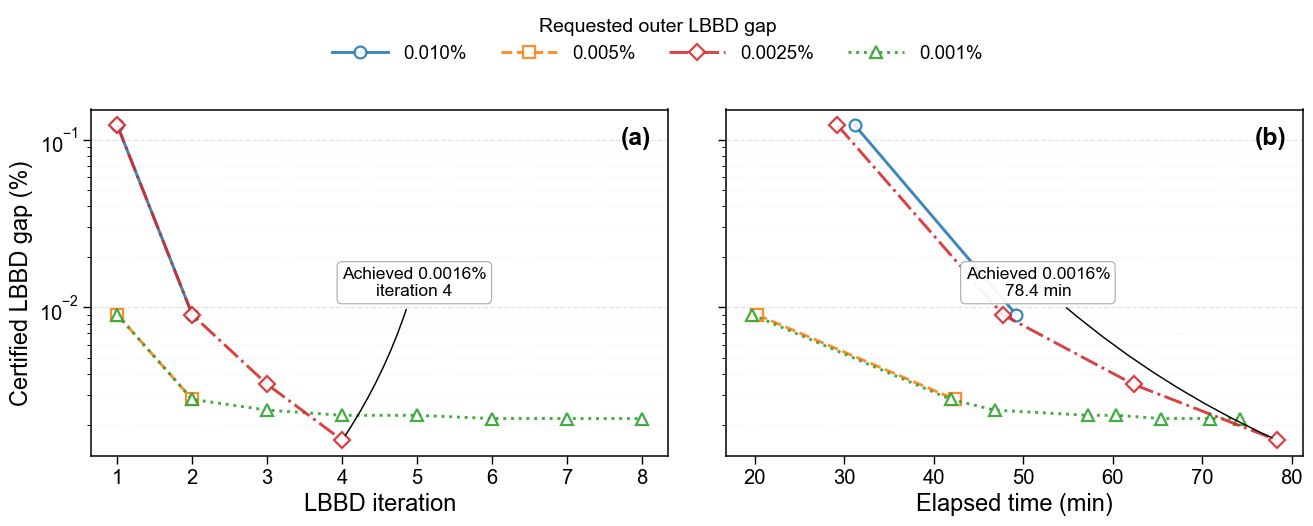

PDF: C:\Users\omkarp\IdeaProjects\VSCode\Large-scale-LBBD-Optimization\runs\tolerance runs\LBBD_tolerance_diagnostics\tolerance_convergence_compound_final.pdf
PNG: C:\Users\omkarp\IdeaProjects\VSCode\Large-scale-LBBD-Optimization\runs\tolerance runs\LBBD_tolerance_diagnostics\tolerance_convergence_compound_final_600dpi.png


In [11]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.ticker import LogLocator, NullFormatter

if "history_long" not in globals():
    history_long = pd.read_csv(
        Path(OUTPUT_DIR) / "tolerance_iteration_history.csv"
    )

plot_data = history_long.copy()

for col in ["target_gap", "iteration", "lbbd_gap", "elapsed_seconds"]:
    plot_data[col] = pd.to_numeric(plot_data[col], errors="coerce")

selected_targets = [1e-4, 5e-5, 2.5e-5, 1e-5]

label_map = {
    1e-4: "0.010%",
    5e-5: "0.005%",
    2.5e-5: "0.0025%",
    1e-5: "0.001%",
}

marker_map = {
    1e-4: "o",
    5e-5: "s",
    2.5e-5: "D",
    1e-5: "^",
}

linestyle_map = {
    1e-4: "-",
    5e-5: "--",
    2.5e-5: "-.",
    1e-5: ":",
}

mpl.rcParams.update({
    "font.size": 15,
    "axes.labelsize": 17,
    "xtick.labelsize": 14.5,
    "ytick.labelsize": 14.5,
    "legend.fontsize": 13.5,
    "legend.title_fontsize": 14,
    "axes.linewidth": 1.1,
    "lines.linewidth": 2.1,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
})

fig, axes = plt.subplots(
    1,
    2,
    figsize=(13.4, 5.25),
    sharey=True,
)

# Plot the 0.0025% trajectory last so that the selected
# successful tight run remains visible where curves overlap.
plot_order = [1e-4, 5e-5, 1e-5, 2.5e-5]

handle_map = {}

for z, target in enumerate(plot_order, start=3):

    mask = np.isclose(
        plot_data["target_gap"],
        target,
        rtol=0,
        atol=1e-12,
    )

    g = (
        plot_data.loc[mask]
        .dropna(subset=["iteration", "lbbd_gap"])
        .sort_values("iteration")
    )

    g = g[g["lbbd_gap"] > 0]

    if g.empty:
        continue

    gap_pct = 100.0 * g["lbbd_gap"]

    line, = axes[0].plot(
        g["iteration"],
        gap_pct,
        linestyle=linestyle_map[target],
        marker=marker_map[target],
        markersize=8.5,
        markerfacecolor="white",
        markeredgewidth=1.6,
        alpha=0.88,
        zorder=z,
        label=label_map[target],
    )

    handle_map[target] = line

    gt = g.dropna(subset=["elapsed_seconds"])

    if not gt.empty:
        axes[1].plot(
            gt["elapsed_seconds"] / 60.0,
            100.0 * gt["lbbd_gap"],
            linestyle=linestyle_map[target],
            marker=marker_map[target],
            markersize=8.5,
            markerfacecolor="white",
            markeredgewidth=1.6,
            alpha=0.88,
            zorder=z,
        )

for ax in axes:

    ax.set_yscale("log")
    ax.set_axisbelow(True)

    # Powers of ten.
    ax.yaxis.set_major_locator(
        LogLocator(base=10.0, subs=(1.0,))
    )

    # Meaningful logarithmic subdivisions within each decade.
    ax.yaxis.set_minor_locator(
        LogLocator(
            base=10.0,
            subs=np.arange(2, 10) * 0.1,
            numticks=100,
        )
    )

    ax.yaxis.set_minor_formatter(NullFormatter())

    # Horizontal grid is the useful reference for an optimality-gap plot.
    ax.grid(
        True,
        which="major",
        axis="y",
        linestyle="--",
        linewidth=0.95,
        alpha=0.34,
    )

    ax.grid(
        True,
        which="minor",
        axis="y",
        linestyle=":",
        linewidth=0.75,
        alpha=0.18,
    )

    # Remove vertical grid lines.
    ax.grid(False, axis="x")

    ax.tick_params(
        direction="out",
        length=5.5,
        width=1.0,
    )

    ax.tick_params(
        which="minor",
        length=3.0,
        width=0.7,
    )

axes[0].set_xlabel("LBBD iteration")
axes[1].set_xlabel("Elapsed time (min)")
axes[0].set_ylabel("Certified LBBD gap (%)")

# Panel labels in upper-right.
axes[0].text(
    0.97,
    0.95,
    "(a)",
    transform=axes[0].transAxes,
    fontsize=18,
    fontweight="bold",
    ha="right",
    va="top",
)

axes[1].text(
    0.97,
    0.95,
    "(b)",
    transform=axes[1].transAxes,
    fontsize=18,
    fontweight="bold",
    ha="right",
    va="top",
)

# Highlight the best successfully attained fixed-inner-tolerance run.
best_target = 2.5e-5

best = (
    plot_data.loc[
        np.isclose(
            plot_data["target_gap"],
            best_target,
            rtol=0,
            atol=1e-12,
        )
    ]
    .dropna(subset=["iteration", "lbbd_gap"])
    .sort_values("iteration")
)

best = best[best["lbbd_gap"] > 0]

if not best.empty:

    p = best.iloc[-1]
    achieved = 100.0 * p["lbbd_gap"]

    # Annotation deliberately placed around the centre of the panel.
    axes[0].annotate(
        f"Achieved {achieved:.4f}%\niteration {int(p['iteration'])}",
        xy=(p["iteration"], achieved),
        xycoords="data",
        xytext=(0.56, 0.50),
        textcoords="axes fraction",
        fontsize=12.5,
        ha="center",
        va="center",
        bbox=dict(
            boxstyle="round,pad=0.28",
            facecolor="white",
            edgecolor="0.65",
            linewidth=0.8,
            alpha=0.94,
        ),
        arrowprops=dict(
            arrowstyle="-",
            linewidth=1.05,
            shrinkA=4,
            shrinkB=4,
            connectionstyle="arc3,rad=-0.08",
        ),
        zorder=30,
    )

    if np.isfinite(p["elapsed_seconds"]):

        elapsed_min = p["elapsed_seconds"] / 60.0

        axes[1].annotate(
            f"Achieved {achieved:.4f}%\n{elapsed_min:.1f} min",
            xy=(elapsed_min, achieved),
            xycoords="data",
            xytext=(0.54, 0.50),
            textcoords="axes fraction",
            fontsize=12.5,
            ha="center",
            va="center",
            bbox=dict(
                boxstyle="round,pad=0.28",
                facecolor="white",
                edgecolor="0.65",
                linewidth=0.8,
                alpha=0.94,
            ),
            arrowprops=dict(
                arrowstyle="-",
                linewidth=1.05,
                shrinkA=4,
                shrinkB=4,
                connectionstyle="arc3,rad=0.08",
            ),
            zorder=30,
        )

legend_order = [1e-4, 5e-5, 2.5e-5, 1e-5]

handles = [
    handle_map[t]
    for t in legend_order
    if t in handle_map
]

labels = [
    label_map[t]
    for t in legend_order
    if t in handle_map
]

fig.legend(
    handles,
    labels,
    title="Requested outer LBBD gap",
    loc="upper center",
    bbox_to_anchor=(0.5, 1.025),
    ncol=4,
    frameon=False,
    handlelength=3.0,
    columnspacing=1.8,
)

fig.tight_layout(rect=[0, 0, 1, 0.86])
fig.subplots_adjust(wspace=0.10)

out_dir = Path(OUTPUT_DIR)
out_dir.mkdir(parents=True, exist_ok=True)

pdf_path = out_dir / "tolerance_convergence_compound_final.pdf"
png_path = out_dir / "tolerance_convergence_compound_final_600dpi.png"

fig.savefig(
    pdf_path,
    format="pdf",
    bbox_inches="tight",
)

fig.savefig(
    png_path,
    dpi=600,
    bbox_inches="tight",
)

plt.show()

print(f"PDF: {pdf_path.resolve()}")
print(f"PNG: {png_path.resolve()}")